# Создание и обучения нейросети


# Практическое задание 0



Создайте модель заданной структуры

In [64]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential()

model.add(Dense(3, input_dim=3))  # Первый слой с 3 нейронами
model.add(Dense(1))               # Второй слой с 1 нейроном

model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
model = Sequential()

model.add(Dense(3, input_dim=3, use_bias=False))  # Первый слой с 3 нейронами
model.add(Dense(1, use_bias=False))               # Второй слой с 1 нейроном

# Вывод весов модели
print("\nВеса модели:")
for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        print(f"Слой {layer.name}:")
        print(f"  Веса: {weights[0].shape}")
        if len(weights) > 1:
            print(f"  Смещение: {weights[1].shape}")
        else:
            print("  Без смещения")


Веса модели:
Слой dense_22:
  Веса: (3, 3)
  Без смещения
Слой dense_23:
  Веса: (3, 1)
  Без смещения


# Практическое задание 1

---

 Распознавание рукописных цифр MNIST

In [66]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных MNIST
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

print(f"Размер обучающей выборки: {x_train_org.shape}")
print(f"Размер тестовой выборки: {x_test_org.shape}")

Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)


In [67]:
# Подготовка данных
# Преобразуем изображения из 28x28 в вектор 784
x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Преобразуем метки в one-hot encoding
CLASS_COUNT = 10
y_train = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test = utils.to_categorical(y_test_org, CLASS_COUNT)

print(f"Форма обучающих данных: {x_train.shape}")
print(f"Форма меток: {y_train.shape}")

Форма обучающих данных: (60000, 784)
Форма меток: (60000, 10)


In [68]:
# Создание архитектуры нейронной сети
model = Sequential()

model.add(Dense(128, input_dim=784, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax')) # Выходной слой

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
#Компиляция модели
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [70]:
# Обучение сети
print("\n" + "="*50)
print("НАЧАЛО ОБУЧЕНИЯ:")
print("="*50)

history = model.fit(
    x_train,                    # Обучающая выборка
    y_train,                    # Метки
    batch_size=128,             # Размер батча
    epochs=15,                  # Количество эпох
    validation_split=0.1,       # 10% данных для проверки
    verbose=1                   # Показывать прогресс
)


НАЧАЛО ОБУЧЕНИЯ:
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8952 - loss: 0.3807 - val_accuracy: 0.9560 - val_loss: 0.1663
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9513 - loss: 0.1707 - val_accuracy: 0.9652 - val_loss: 0.1231
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9652 - loss: 0.1234 - val_accuracy: 0.9683 - val_loss: 0.1105
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9726 - loss: 0.0954 - val_accuracy: 0.9740 - val_loss: 0.0876
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9776 - loss: 0.0765 - val_accuracy: 0.9745 - val_loss: 0.0812
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9821 - loss: 0.0622 - val_accuracy: 0.9765 - val_loss: 0.0804
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9850 - loss: 0.0530 - val_accuracy: 0.9737 - val_loss: 0.0813
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9875 - loss: 0.0446 

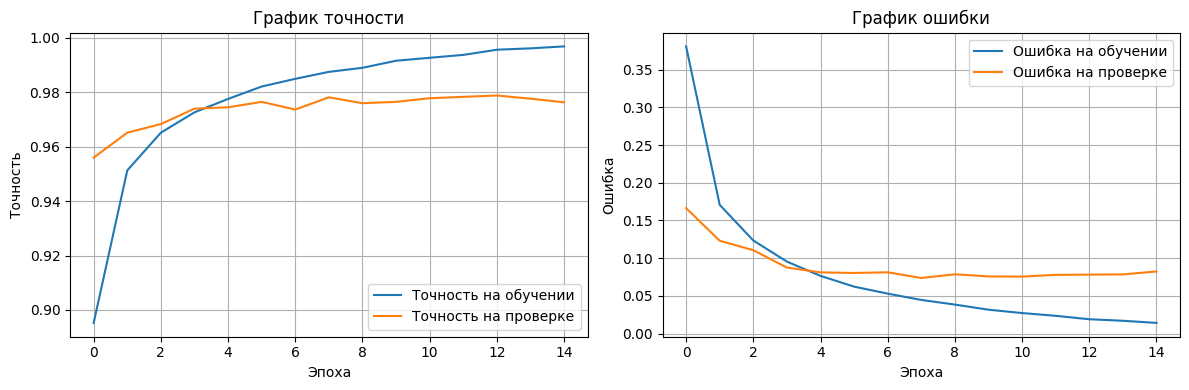

In [71]:
# Графики точности и ошибки
plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на проверке')
plt.title('График точности')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid(True)

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Ошибка на обучении')
plt.plot(history.history['val_loss'], label='Ошибка на проверке')
plt.title('График ошибки')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

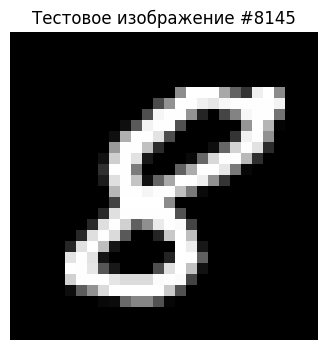

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

Результат распознавания:
Предсказанная цифра: 8
Вероятности по классам:
  0: 0.0000
  1: 0.0000
  2: 0.0000
  3: 0.0000
  4: 0.0000
  5: 0.0000
  6: 0.0000
  7: 0.0000
  8: 1.0000
  9: 0.0000

Правильный ответ: 8
Предсказание ВЕРНОЕ!

Оценка на тестовой выборке:
  Точность: 0.9790 (97.90%)
  Ошибка: 0.0748


In [72]:
# Проверка работы сети на случайном примере из тестовой выборки
n_rec = np.random.randint(0, x_test.shape[0])

# Отображаем изображение
plt.figure(figsize=(4, 4))
plt.imshow(x_test_org[n_rec], cmap='gray')
plt.title(f'Тестовое изображение #{n_rec}')
plt.axis('off')
plt.show()

# Подготавливаем данные для предсказания
x_sample = x_test[n_rec]
x_sample = np.expand_dims(x_sample, axis=0)
# Добавляем размерность батча

# Делаем предсказание
prediction = model.predict(x_sample)
predicted_class = np.argmax(prediction)

# Выводим результат
print(f"\nРезультат распознавания:")
print(f"Предсказанная цифра: {predicted_class}")
print(f"Вероятности по классам:")
for i, prob in enumerate(prediction[0]):
    print(f"  {i}: {prob:.4f}")

# Сравниваем с правильным ответом
print(f"\nПравильный ответ: {y_test_org[n_rec]}")
print(f"Предсказание {'ВЕРНОЕ' if predicted_class == y_test_org[n_rec] else 'НЕВЕРНОЕ'}!")

# Оценка качества на всей тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nОценка на тестовой выборке:")
print(f"  Точность: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Ошибка: {test_loss:.4f}")

# Задание 2

---

Определение цифр на реальных фотографиях

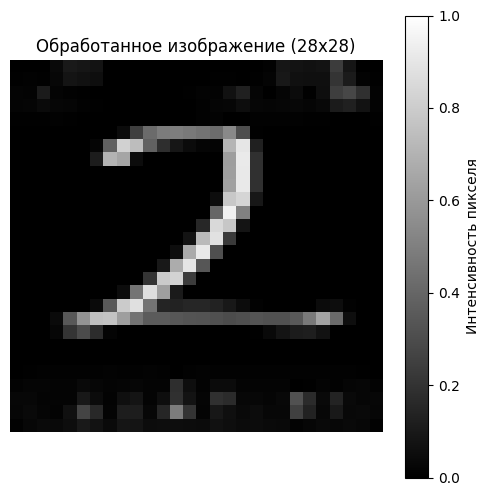

In [82]:
import numpy as np
from PIL import Image

# Загрузка изображения
img = Image.open('IMG_9550.png')

# Преобразование в оттенки серого
img = img.convert('L')

# Изменение размера до 28x28
img = img.resize((28, 28))

# Инвертирование цветов (если цифра черная на белом фоне → белая на черном)
img = np.array(img)
img = 255 - img  # инверсия

# Нормализация
img = img.astype('float32') / 255.0

# Преобразование в вектор (как в MNIST)
img_vector = img.reshape(1, 784)  # для полносвязной сети

plt.figure(figsize=(6, 6))
plt.imshow(img_vector.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
plt.title('Обработанное изображение (28x28)')
plt.colorbar(label='Интенсивность пикселя')
plt.axis('off')
plt.show()

In [83]:
# Делаем предсказание
prediction = model.predict(img_vector)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

# Вывод результатов
print("\n" + "="*50)
print("РЕЗУЛЬТАТ РАСПОЗНАВАНИЯ:")
print("="*50)
print(f"Предсказанная цифра: {predicted_class}")
print(f"Уверенность: {confidence*100:.1f}%")

print("\nВероятности по классам:")
for i, prob in enumerate(prediction[0]):
    bar = "█" * int(prob * 50)
    print(f"  {i}: {prob*100:5.1f}% {bar}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

РЕЗУЛЬТАТ РАСПОЗНАВАНИЯ:
Предсказанная цифра: 2
Уверенность: 67.4%

Вероятности по классам:
  0:   0.0% 
  1:   0.1% 
  2:  67.4% █████████████████████████████████
  3:   0.8% 
  4:   0.0% 
  5:   0.0% 
  6:   0.0% 
  7:  31.7% ███████████████
  8:   0.0% 
  9:   0.0% 
